# 03. LBP Cascade Face Detection
Mục tiêu:
- Dùng **LBP Cascade** để phát hiện khuôn mặt trên ảnh full-size đã preprocessing.
- Tune tham số trên tập validation.
- Đánh giá final trên tập test.
- Vẽ ground-truth bbox và predicted bbox để kiểm tra trực quan.
- Lưu tham số tốt nhất ra file XML để dùng lại trong demo/app.

Ghi chú:
- LBP Cascade là phương pháp **traditional computer vision**, không phải deep learning.
- Notebook này dùng lại cấu trúc đánh giá giống notebook Haar Cascade để kết quả dễ so sánh.

## 1. Import thư viện

In [1]:
from pathlib import Path
import time
import random
import urllib.request
import xml.etree.ElementTree as ET

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

## 2. Import cấu hình project

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "src" / "utils" / "config.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Using project root: {project_root}")

Using project root: D:\image-processing-project


In [3]:
from src.utils.config import *

from src.utils.preprocess_detection import (
    read_yolo_label_file,
    box_iou
)

VAL_IMAGES = VAL_DETECTION / "images"
VAL_LABELS = VAL_DETECTION / "labels"

TEST_IMAGES = TEST_DETECTION / "images"
TEST_LABELS = TEST_DETECTION / "labels"

DETECTION_MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("VAL_IMAGES:", VAL_IMAGES)
print("VAL_LABELS:", VAL_LABELS)
print("TEST_IMAGES:", TEST_IMAGES)
print("TEST_LABELS:", TEST_LABELS)
print("DETECTION_MODEL_DIR:", DETECTION_MODEL_DIR)

VAL_IMAGES: D:\image-processing-project\data\processed\face_detection\val\images
VAL_LABELS: D:\image-processing-project\data\processed\face_detection\val\labels
TEST_IMAGES: D:\image-processing-project\data\processed\face_detection\test\images
TEST_LABELS: D:\image-processing-project\data\processed\face_detection\test\labels
DETECTION_MODEL_DIR: D:\image-processing-project\models\face_detection


## 3. Kiểm tra dữ liệu đã preprocessing

In [4]:
def check_detection_folder(images_dir, labels_dir):
    images_dir = Path(images_dir)
    labels_dir = Path(labels_dir)

    image_paths = sorted([
        p for p in images_dir.glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])

    label_paths = sorted(labels_dir.glob("*.txt"))

    print("Images dir exists:", images_dir.exists())
    print("Labels dir exists:", labels_dir.exists())
    print("Number of images:", len(image_paths))
    print("Number of labels:", len(label_paths))

    if len(image_paths) == 0:
        raise RuntimeError(
            "Không tìm thấy ảnh đã preprocessing. "
            "Hãy chạy notebook 1_preprocessing.ipynb trước."
        )

    return image_paths, label_paths


val_image_paths, val_label_paths = check_detection_folder(
    images_dir=VAL_IMAGES,
    labels_dir=VAL_LABELS
)

test_image_paths, test_label_paths = check_detection_folder(
    images_dir=TEST_IMAGES,
    labels_dir=TEST_LABELS
)

Images dir exists: True
Labels dir exists: True
Number of images: 3286
Number of labels: 3286
Images dir exists: True
Labels dir exists: True
Number of images: 3287
Number of labels: 3287


## 4. Load LBP Cascade pretrained

OpenCV bản `pip install opencv-python` thường có sẵn Haar Cascade nhưng **có thể không có sẵn LBP Cascade**.  
Vì vậy cell dưới đây sẽ:
1. Tìm file `lbpcascade_frontalface.xml` trong thư mục model của project.
2. Nếu chưa có, thử tìm trong thư mục data của OpenCV.
3. Nếu vẫn chưa có, tự tải file LBP Cascade từ repository OpenCV.
4. Nếu tải thất bại, báo lỗi và hướng dẫn đặt file thủ công.

In [5]:
LBP_CASCADE_FILENAME = "lbpcascade_frontalface.xml"
LBP_CASCADE_PATH = DETECTION_MODEL_DIR / LBP_CASCADE_FILENAME

OPENCV_LBP_URLS = [
    "https://raw.githubusercontent.com/opencv/opencv/4.x/data/lbpcascades/lbpcascade_frontalface.xml",
    "https://raw.githubusercontent.com/opencv/opencv/master/data/lbpcascades/lbpcascade_frontalface.xml"
]


def find_existing_lbp_cascade():
    """
    Tìm file LBP Cascade ở các vị trí thường gặp.
    """
    candidate_paths = [
        LBP_CASCADE_PATH,
        Path(cv2.data.haarcascades) / LBP_CASCADE_FILENAME,
        Path(cv2.data.haarcascades).parent / "lbpcascades" / LBP_CASCADE_FILENAME,
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    return None


def download_lbp_cascade(save_path=LBP_CASCADE_PATH):
    """
    Tải lbpcascade_frontalface.xml nếu local chưa có.
    """
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)

    last_error = None

    for url in OPENCV_LBP_URLS:
        try:
            print("Downloading LBP Cascade from:")
            print(url)

            urllib.request.urlretrieve(url, save_path)

            if save_path.exists() and save_path.stat().st_size > 0:
                print("Downloaded to:", save_path)
                return save_path

        except Exception as error:
            last_error = error
            print("Download failed:", error)

    raise RuntimeError(
        "Không thể tải lbpcascade_frontalface.xml tự động.\\n"
        f"Hãy tải file thủ công và đặt tại: {save_path}\\n"
        "Gợi ý nguồn: opencv/data/lbpcascades/lbpcascade_frontalface.xml\\n"
        f"Lỗi cuối cùng: {last_error}"
    )


def prepare_lbp_cascade_file():
    existing_path = find_existing_lbp_cascade()

    if existing_path is not None:
        print("Found existing LBP Cascade file:")
        print(existing_path)

        # Copy về thư mục models/face_detection để quản lý thống nhất
        if existing_path != LBP_CASCADE_PATH:
            LBP_CASCADE_PATH.write_bytes(existing_path.read_bytes())
            print("Copied to project model folder:")
            print(LBP_CASCADE_PATH)

        return LBP_CASCADE_PATH

    return download_lbp_cascade(LBP_CASCADE_PATH)


def load_lbp_detector():
    cascade_path = prepare_lbp_cascade_file()

    detector = cv2.CascadeClassifier(str(cascade_path))

    if detector.empty():
        raise RuntimeError(
            "Cannot load LBP Cascade model. "
            "File XML có thể bị thiếu, sai định dạng hoặc tải chưa hoàn chỉnh."
        )

    return detector, cascade_path


lbp_detector, lbp_cascade_path = load_lbp_detector()

print("LBP Cascade loaded successfully.")
print("Cascade path:", lbp_cascade_path)

https://raw.githubusercontent.com/opencv/opencv/4.x/data/lbpcascades/lbpcascade_frontalface.xml
Downloaded to: D:\image-processing-project\models\face_detection\lbpcascade_frontalface.xml
LBP Cascade loaded successfully.
Cascade path: D:\image-processing-project\models\face_detection\lbpcascade_frontalface.xml


## 5. Hàm phát hiện khuôn mặt bằng LBP Cascade

In [6]:
def detect_faces_lbp(
    gray_image,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(30, 30)
):
    """
    Detect faces using LBP Cascade.

    Input:
        gray_image: ảnh grayscale đã preprocessing

    Output:
        boxes_xyxy: list bbox theo format [x1, y1, x2, y2]
        elapsed_time: thời gian xử lý
    """

    start_time = time.time()

    faces_xywh = lbp_detector.detectMultiScale(
        gray_image,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size
    )

    elapsed_time = time.time() - start_time

    boxes_xyxy = []

    for (x, y, w, h) in faces_xywh:
        boxes_xyxy.append([
            int(x),
            int(y),
            int(x + w),
            int(y + h)
        ])

    return boxes_xyxy, elapsed_time

## 6. Hàm vẽ bbox

In [7]:
def draw_boxes(
    image,
    boxes,
    color=(0, 255, 0),
    thickness=2,
    label=None,
    show=False,
    title="Detection Result",
    figsize=(8, 6)
):
    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        output = image.copy()

    for box in boxes:
        x1, y1, x2, y2 = box

        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            thickness
        )

        if label is not None:
            cv2.putText(
                output,
                label,
                (x1, max(0, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    if show:
        plt.figure(figsize=figsize)
        plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return output

## 7. Hàm đánh giá một ảnh

In [8]:
def evaluate_single_image(pred_boxes, gt_boxes, iou_threshold=0.5):
    """
    Evaluate detection result for one image.

    Logic:
        Một prediction là TP nếu IoU >= threshold với một GT box chưa được match.
    """

    matched_gt = set()

    true_positive = 0
    false_positive = 0

    iou_values = []

    for pred_box in pred_boxes:
        best_iou = 0.0
        best_gt_idx = -1

        for gt_idx, gt_box in enumerate(gt_boxes):
            if gt_idx in matched_gt:
                continue

            iou = box_iou(pred_box, gt_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_iou >= iou_threshold:
            true_positive += 1
            matched_gt.add(best_gt_idx)
            iou_values.append(best_iou)
        else:
            false_positive += 1

    false_negative = len(gt_boxes) - len(matched_gt)

    return {
        "tp": true_positive,
        "fp": false_positive,
        "fn": false_negative,
        "matched_ious": iou_values
    }

## 8. Hàm đánh giá toàn bộ tập ảnh

In [9]:
def evaluate_lbp(
    images_dir,
    labels_dir,
    scale_factor=1.1,
    min_neighbors=5,
    min_size=(30, 30),
    iou_threshold=0.5,
    max_images=None
):
    image_paths = sorted([
        p for p in Path(images_dir).glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])

    if max_images is not None:
        image_paths = image_paths[:max_images]

    records = []

    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_time = 0.0
    all_ious = []

    for image_path in tqdm(image_paths, desc="Evaluating LBP Cascade"):
        gray_image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if gray_image is None:
            continue

        height, width = gray_image.shape[:2]

        label_path = Path(labels_dir) / f"{image_path.stem}.txt"

        gt_boxes = read_yolo_label_file(
            label_path=label_path,
            image_width=width,
            image_height=height
        )

        pred_boxes, elapsed_time = detect_faces_lbp(
            gray_image=gray_image,
            scale_factor=scale_factor,
            min_neighbors=min_neighbors,
            min_size=min_size
        )

        result = evaluate_single_image(
            pred_boxes=pred_boxes,
            gt_boxes=gt_boxes,
            iou_threshold=iou_threshold
        )

        total_tp += result["tp"]
        total_fp += result["fp"]
        total_fn += result["fn"]
        total_time += elapsed_time
        all_ious.extend(result["matched_ious"])

        records.append({
            "image_name": image_path.name,
            "num_gt": len(gt_boxes),
            "num_pred": len(pred_boxes),
            "tp": result["tp"],
            "fp": result["fp"],
            "fn": result["fn"],
            "time": elapsed_time
        })

    evaluated_images = len(image_paths)

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    avg_iou = np.mean(all_ious) if len(all_ious) > 0 else 0.0
    avg_time = total_time / evaluated_images if evaluated_images > 0 else 0.0
    fps = 1.0 / avg_time if avg_time > 0 else 0.0

    summary = {
        "method": "LBP Cascade",
        "scale_factor": scale_factor,
        "min_neighbors": min_neighbors,
        "min_size": min_size,
        "iou_threshold": iou_threshold,
        "total_images": evaluated_images,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "avg_iou": avg_iou,
        "avg_time": avg_time,
        "fps": fps
    }

    records_df = pd.DataFrame(records)

    return summary, records_df

## 9. Tune LBP Cascade trên validation set

In [10]:
lbp_param_grid = [
    {
        "scale_factor": 1.05,
        "min_neighbors": 3,
        "min_size": (20, 20)
    },
    {
        "scale_factor": 1.05,
        "min_neighbors": 5,
        "min_size": (30, 30)
    },
    {
        "scale_factor": 1.10,
        "min_neighbors": 3,
        "min_size": (20, 20)
    },
    {
        "scale_factor": 1.10,
        "min_neighbors": 5,
        "min_size": (30, 30)
    },
    {
        "scale_factor": 1.10,
        "min_neighbors": 7,
        "min_size": (40, 40)
    },
    {
        "scale_factor": 1.20,
        "min_neighbors": 5,
        "min_size": (40, 40)
    }
]

In [11]:
tuning_results = []

for params in lbp_param_grid:
    print("Testing params:", params)

    summary, _ = evaluate_lbp(
        images_dir=VAL_IMAGES,
        labels_dir=VAL_LABELS,
        scale_factor=params["scale_factor"],
        min_neighbors=params["min_neighbors"],
        min_size=params["min_size"],
        iou_threshold=0.5,
        max_images=None
    )

    tuning_results.append(summary)

tuning_df = pd.DataFrame(tuning_results)

tuning_df = tuning_df.sort_values(
    by="f1",
    ascending=False
).reset_index(drop=True)

tuning_df

Testing params: {'scale_factor': 1.05, 'min_neighbors': 3, 'min_size': (20, 20)}


Evaluating LBP Cascade: 100%|██████████| 3286/3286 [03:16<00:00, 16.71it/s]


Testing params: {'scale_factor': 1.05, 'min_neighbors': 5, 'min_size': (30, 30)}


Evaluating LBP Cascade: 100%|██████████| 3286/3286 [02:49<00:00, 19.41it/s]


Testing params: {'scale_factor': 1.1, 'min_neighbors': 3, 'min_size': (20, 20)}


...

Testing params: {'scale_factor': 1.1, 'min_neighbors': 7, 'min_size': (40, 40)}


Evaluating LBP Cascade: 100%|██████████| 3286/3286 [01:19<00:00, 41.26it/s]


Testing params: {'scale_factor': 1.2, 'min_neighbors': 5, 'min_size': (40, 40)}


Evaluating LBP Cascade: 100%|██████████| 3286/3286 [00:56<00:00, 58.14it/s]


,method,scale_factor,min_neighbors,min_size,iou_threshold,total_images,tp,fp,fn,precision,recall,f1,avg_iou,avg_time,fps
0,LBP Cascade,1.10,3,"(20, 20)",0.5,3286,4665,3078,20227,0.602480,0.187410,0.285889,0.698251,0.028005,35.707513
1,LBP Cascade,1.05,5,"(30, 30)",0.5,3286,4601,3860,20291,0.543789,0.184839,0.275897,0.695444,0.043488,22.994714
2,LBP Cascade,1.05,3,"(20, 20)",0.5,3286,5529,10131,19363,0.353065,0.222120,0.272687,0.694327,0.051622,19.371638
3,LBP Cascade,1.10,5,"(30, 30)",0.5,3286,3768,960,21124,0.796954,0.151374,0.254423,0.698405,0.020962,47.705037
4,LBP Cascade,1.10,7,"(40, 40)",0.5,3286,3031,415,21861,0.879571,0.121766,0.213918,0.698816,0.017020,58.754147
5,LBP Cascade,1.20,5,"(40, 40)",0.5,3286,2784,256,22108,0.915789,0.111843,0.199341,0.701769,0.010158,98.448582


## 10. Lấy bộ tham số tốt nhất

In [62]:
best_row = tuning_df.iloc[3]

best_scale_factor = float(best_row["scale_factor"])
best_min_neighbors = int(best_row["min_neighbors"])
best_min_size = best_row["min_size"]

# Khi lưu/đọc từ DataFrame, tuple đôi khi có thể thành string.
# Cell này đảm bảo best_min_size luôn là tuple(int, int).
if isinstance(best_min_size, str):
    best_min_size = best_min_size.strip("()").split(",")
    best_min_size = (int(best_min_size[0]), int(best_min_size[1]))
else:
    best_min_size = tuple(best_min_size)

print("Best LBP params:")
print("scale_factor:", best_scale_factor)
print("min_neighbors:", best_min_neighbors)
print("min_size:", best_min_size)

best_row

Best LBP params:
scale_factor: 1.1
min_neighbors: 5
min_size: (30, 30)


method           LBP Cascade
scale_factor             1.1
min_neighbors              5
min_size            (30, 30)
iou_threshold            0.5
total_images            3286
tp                      3768
fp                       960
fn                     21124
precision           0.796954
recall              0.151374
f1                  0.254423
avg_iou             0.698405
avg_time            0.020962
fps                47.705037
Name: 3, dtype: object

## 11. Đánh giá LBP Cascade trên test set

In [63]:
test_summary, test_records_df = evaluate_lbp(
    images_dir=TEST_IMAGES,
    labels_dir=TEST_LABELS,
    scale_factor=best_scale_factor,
    min_neighbors=best_min_neighbors,
    min_size=best_min_size,
    iou_threshold=0.5,
    max_images=None
)

test_summary

Evaluating LBP Cascade:   0%|          | 0/3287 [00:00<?, ?it/s]

Evaluating LBP Cascade: 100%|██████████| 3287/3287 [02:31<00:00, 21.69it/s]


{'method': 'LBP Cascade',
 'scale_factor': 1.1,
 'min_neighbors': 5,
 'min_size': (30, 30),
 'iou_threshold': 0.5,
 'total_images': 3287,
 'tp': 3520,
 'fp': 983,
 'fn': 21595,
 'precision': 0.7817010881634466,
 'recall': 0.14015528568584512,
 'f1': 0.23769329461813765,
 'avg_iou': np.float64(0.6989235258550353),
 'avg_time': 0.035374814629155815,
 'fps': 28.26869936940399}

## 12. Trực quan hóa một ảnh random từ test set

Image: 8f8be309f449705e.png
GT boxes: 2
Pred boxes: 2
TP: 2
FP: 0
FN: 0
Matched IoUs: [0.6038038496791934, 0.5899746485365291]
Processing time: 0.0181 seconds


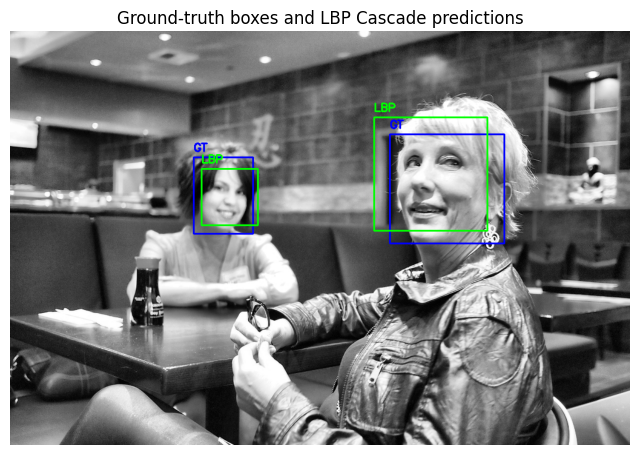

In [77]:
test_image_paths = sorted([
    p for p in (TEST_DETECTION / "images").glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

sample_image_path = random.choice(test_image_paths)
sample_label_path = TEST_DETECTION / "labels" / f"{sample_image_path.stem}.txt"

# Đọc ảnh test đã preprocessing
gray_image = cv2.imread(str(sample_image_path), cv2.IMREAD_GRAYSCALE)

height, width = gray_image.shape[:2]

# Đọc ground-truth bbox
gt_boxes = read_yolo_label_file(
    label_path=sample_label_path,
    image_width=width,
    image_height=height
)

# Dự đoán bbox bằng LBP Cascade
pred_boxes, elapsed_time = detect_faces_lbp(
    gray_image=gray_image,
    scale_factor=best_scale_factor,
    min_neighbors=best_min_neighbors,
    min_size=best_min_size
)

# Đánh giá ảnh này
result = evaluate_single_image(
    pred_boxes=pred_boxes,
    gt_boxes=gt_boxes,
    iou_threshold=0.5
)

# Vẽ GT màu xanh dương, prediction màu xanh lá
vis_image = draw_boxes(
    image=gray_image,
    boxes=gt_boxes,
    color=(255, 0, 0),
    label="GT"
)

vis_image = draw_boxes(
    image=vis_image,
    boxes=pred_boxes,
    color=(0, 255, 0),
    label="LBP"
)

print("Image:", sample_image_path.name)
print("GT boxes:", len(gt_boxes))
print("Pred boxes:", len(pred_boxes))
print("TP:", result["tp"])
print("FP:", result["fp"])
print("FN:", result["fn"])
print("Matched IoUs:", result["matched_ious"])
print("Processing time:", round(elapsed_time, 4), "seconds")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title("Ground-truth boxes and LBP Cascade predictions")
plt.axis("off")
plt.show()

## 13. Lưu kết quả và tham số tốt nhất

In [79]:
params_xml_path = DETECTION_MODEL_DIR / "best_lbp_params.xml"


# Lưu best params dạng XML
root = ET.Element("LBPCascadeBestParams")

ET.SubElement(root, "cascade_file").text = str(lbp_cascade_path)
ET.SubElement(root, "scale_factor").text = str(best_scale_factor)
ET.SubElement(root, "min_neighbors").text = str(best_min_neighbors)

min_size_node = ET.SubElement(root, "min_size")
ET.SubElement(min_size_node, "width").text = str(best_min_size[0])
ET.SubElement(min_size_node, "height").text = str(best_min_size[1])

ET.SubElement(root, "gamma").text = "1.0"
ET.SubElement(root, "clahe_clip_limit").text = "2.0"
ET.SubElement(root, "clahe_tile_grid_size").text = "8,8"
ET.SubElement(root, "iou_threshold").text = "0.5"

tree = ET.ElementTree(root)

tree.write(
    params_xml_path,
    encoding="utf-8",
    xml_declaration=True
)

print("Saved best LBP params to:")
print(params_xml_path)

Saved best LBP params to:
D:\image-processing-project\models\face_detection\best_lbp_params.xml
